In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.cluster import (
    KMeans,
    MiniBatchKMeans,
    AgglomerativeClustering,
    DBSCAN,
    MeanShift,
    SpectralClustering,
    Birch,
    OPTICS
)

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv(r"C:\ds and AI\ALL DATASETS\bitcoin_dataset.csv")
print(df.shape)
df.head()


(4280, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [4]:
df.info()

df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 4280 entries, 0 to 4279
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4280 non-null   str    
 1   Open       4280 non-null   float64
 2   High       4280 non-null   float64
 3   Low        4280 non-null   float64
 4   Close      4280 non-null   float64
 5   Adj Close  4280 non-null   float64
 6   Volume     4280 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 276.0 KB


,count,mean,std,min,25%,50%,75%,max
Open,4280.0,2.862333e+04,3.244220e+04,1.768970e+02,3.452187e+03,1.153673e+04,4.640147e+04,1.247521e+05
High,4280.0,2.918832e+04,3.298601e+04,2.117310e+02,3.504092e+03,1.185033e+04,4.743259e+04,1.261981e+05
Low,4280.0,2.801975e+04,3.185279e+04,1.715100e+02,3.391943e+03,1.128841e+04,4.518417e+04,1.231960e+05
Close,4280.0,2.863645e+04,3.244245e+04,1.781030e+02,3.458814e+03,1.156433e+04,4.644692e+04,1.247525e+05
Adj Close,4280.0,2.863645e+04,3.244245e+04,1.781030e+02,3.458814e+03,1.156433e+04,4.644692e+04,1.247525e+05
Volume,4280.0,2.230348e+10,2.294359e+10,5.914570e+06,1.676575e+09,1.802679e+10,3.446429e+10,3.509679e+11


In [5]:
print(df.isnull().sum())

imputer = SimpleImputer(strategy="median")

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

df['Daily_Return'] = (
    (df['Close'] - df['Open']) / df['Open']
)

df['Price_Range'] = (
    (df['High'] - df['Low']) / df['Low']
)

df['Volatility'] = (
    df['Close'].rolling(7).std()
)

df['Volume_Change'] = (
    df['Volume'].pct_change()
)

df['MA_7'] = (
    df['Close'].rolling(7).mean()
)

df['MA_30'] = (
    df['Close'].rolling(30).mean()
)

df['Momentum'] = (
    df['Close'] - df['Close'].shift(10)
)

In [15]:
df = df.bfill()
df = df.ffill()

In [8]:
features = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Daily_Return',
    'Price_Range',
    'Volatility',
    'Volume_Change',
    'MA_7',
    'MA_30',
    'Momentum'
]

X = df[features]

In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [17]:
from sklearn.metrics.pairwise import euclidean_distances

# Remove NaN values
X_scaled_clean = np.nan_to_num(X_scaled, nan=0.0)

distance_matrix = euclidean_distances(
    X_scaled_clean[:100]
)

distance_matrix.shape

(100, 100)

In [19]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled_clean)

print(
    pca.explained_variance_ratio_
)

[0.59499906 0.12205011]


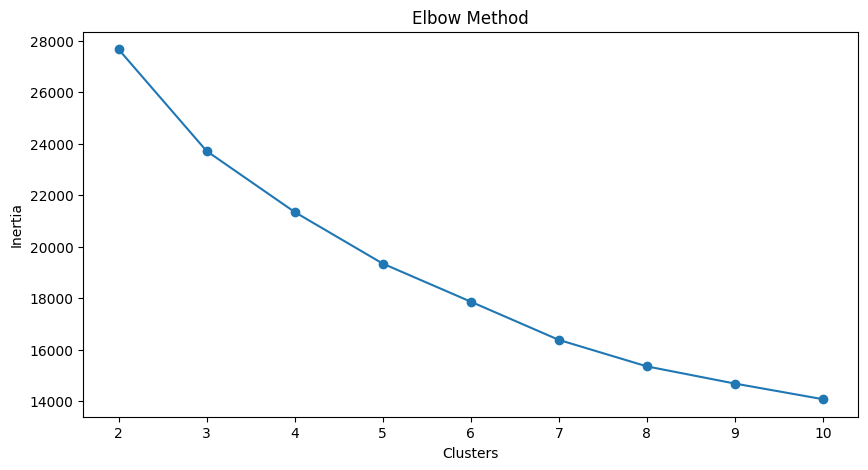

In [21]:
inertia = []

for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    km.fit(X_scaled_clean)

    inertia.append(km.inertia_)

plt.figure(figsize=(10,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

In [23]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(
    X_scaled_clean
)

In [25]:
agg = AgglomerativeClustering(
    n_clusters=4
)

agg_labels = agg.fit_predict(
    X_scaled_clean
)

In [27]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=8
)

dbscan_labels = dbscan.fit_predict(
    X_scaled_clean
)

In [29]:
gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

gmm_labels = gmm.fit_predict(
    X_scaled_clean
)

In [30]:
optics = OPTICS(
    min_samples=8
)

optics_labels = optics.fit_predict(
    X_scaled_clean
)

In [32]:
results = []

models = {
    "KMeans": kmeans_labels,
    "Agglomerative": agg_labels,
    "GMM": gmm_labels
}

for name, labels in models.items():

    sil = silhouette_score(
        X_scaled_clean,
        labels
    )

    dbi = davies_bouldin_score(
        X_scaled_clean,
        labels
    )

    chi = calinski_harabasz_score(
        X_scaled_clean,
        labels
    )

    results.append(
        [name,sil,dbi,chi]
    )

results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Silhouette",
        "DB Index",
        "Calinski"
    ]
)

results.sort_values(
    "Silhouette",
    ascending=False
)

,Model,Silhouette,DB Index,Calinski
1,Agglomerative,0.385362,1.534893,1856.788840
0,KMeans,0.384415,1.316443,2001.611503
2,GMM,0.110496,2.161179,1229.896469


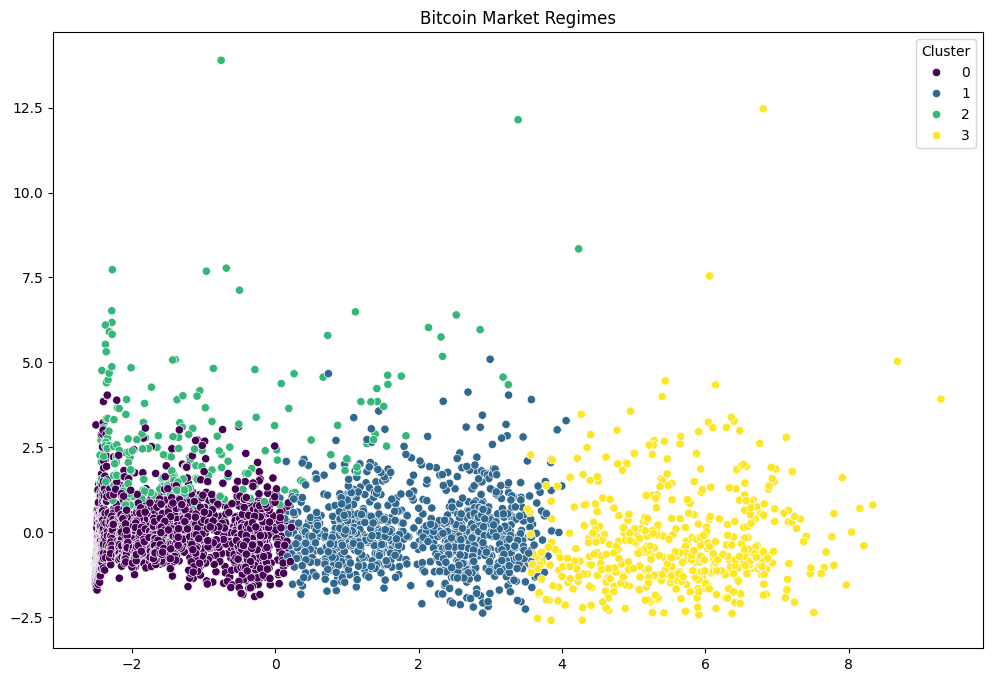

In [33]:
df["Cluster"] = kmeans_labels

plt.figure(figsize=(12,8))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["Cluster"],
    palette="viridis"
)

plt.title(
    "Bitcoin Market Regimes"
)

plt.show()

In [36]:
print(df.columns.tolist())

['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Daily_Return', 'Price_Range', 'Volatility', 'Volume_Change', 'MA_7', 'MA_30', 'Momentum', 'Cluster']


In [37]:
clustered_df = pd.read_csv("clustered_bitcoin.csv")

print(clustered_df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Daily_Return', 'Price_Range', 'Volatility', 'Volume_Change', 'MA_7',
       'MA_30', 'Momentum', 'Cluster'],
      dtype='str')


In [38]:
df = pd.read_csv("clustered_bitcoin.csv")

if "Cluster" not in df.columns:

    st.error(
        "Cluster column not found. Please run train_model.py first."
    )

    st.stop()

In [39]:
df['Daily_Return'] = (
    (df['Close'] - df['Open']) /
    df['Open']
)

df['Price_Range'] = (
    (df['High'] - df['Low']) /
    df['Low']
)

df['Volatility'] = (
    df['Close'].rolling(7).std()
)

df['Volume_Change'] = (
    df['Volume'].pct_change()
)

df['MA_7'] = (
    df['Close'].rolling(7).mean()
)

df['MA_30'] = (
    df['Close'].rolling(30).mean()
)

df['Momentum'] = (
    df['Close'] -
    df['Close'].shift(10)
)

df = df.bfill()

In [40]:
features = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Daily_Return',
    'Price_Range',
    'Volatility',
    'Volume_Change',
    'MA_7',
    'MA_30',
    'Momentum'
]

X = df[features]

X_scaled = scaler.transform(X)

df["Cluster"] = model.predict(X_scaled)

In [41]:
df["Cluster"].nunique()

4